# 第 3 章　大數據收集與資料前處理實戰

這是「醫學生的機器學習入門」第 3 章的配套 notebook。建議搭配網站章節一起讀：網站負責講直覺與觀念，這份 notebook 負責讓你親手跑一次。

- **在 Colab 執行**：上方選單「執行階段 → 全部執行」即可，不需要安裝額外套件（`requests`、`beautifulsoup4` 都已預裝）。
- **網路**：第一部分會連到 UCI、WHO 與 OpenML。若網路或對方伺服器暫時失敗，程式會自動改用**離線備用資料**並清楚印出提示，後面的儲存格仍然可以跑。
- **圖上文字用英文**：Colab 預設沒有中文字型，中文會變成方塊。

> 本 notebook 的醫學資料是公開教學資料集，僅供學習，不構成臨床建議。

## 0. 環境與版本

先印出版本。本教材以 Colab 現況（scikit-learn 1.6 / pandas 2.2）為底線，也在較新的 pandas 3 / scikit-learn 1.9 測過。

In [1]:
import io
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn

print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

# scikit-learn 1.6 + SciPy 1.16 (the Colab combo) prints a harmless solver-option notice
warnings.filterwarnings("ignore", message="Unknown solver options")

Python 3.12.2
numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


## 1. 資料從哪裡來

### 1-1 直接讀 CSV 網址

UCI Machine Learning Repository 的 Chronic Kidney Disease（慢性腎臟病）資料集（id 336，CC BY 4.0）有一個直接的 CSV 網址。我們先用 `requests` 下載（設定 `timeout`，避免網路卡住時整本 notebook 停住），再交給 pandas。

下一格是**離線備用資料產生器**：只有在下載失敗時才會用到。它產生欄位相同的**模擬資料**，數字不是真的病人，只讓後面的程式碼能繼續練習。可以先略過不讀。

In [2]:
def make_fake_ckd(n_ckd=250, n_healthy=150, seed=42):
    """Synthetic stand-in with the same columns as UCI CKD (offline practice only)."""
    g = np.random.default_rng(seed)
    y = np.array(["ckd"] * n_ckd + ["notckd"] * n_healthy)
    sick = y == "ckd"
    n = len(y)
    # column: (mean if CKD, mean if healthy, sd)
    spec = {"age": (55, 46, 15), "bp": (80, 71, 10), "bgr": (170, 110, 60),
            "bu": (75, 33, 40), "sod": (133, 141, 6), "pot": (4.8, 4.3, 0.8),
            "hemo": (10.6, 15.2, 2.0), "pcv": (32, 46, 6), "wbcc": (8900, 7700, 2500),
            "rbcc": (3.9, 5.4, 0.8)}
    df = pd.DataFrame({c: np.round(np.where(sick, g.normal(a, s, n), g.normal(b, s, n)), 1)
                       for c, (a, b, s) in spec.items()})
    df["sg"] = np.where(sick, g.choice([1.005, 1.010, 1.015], n), g.choice([1.020, 1.025], n))
    df["al"] = np.where(sick, g.integers(0, 5, n), 0).astype(float)
    df["su"] = np.where(sick, g.integers(0, 3, n), 0).astype(float)
    df["sc"] = np.round(np.where(sick, g.lognormal(1.0, 0.8, n), g.normal(0.9, 0.2, n)), 1)
    # column: (P(abnormal) if CKD, P(abnormal) if healthy, abnormal label, normal label)
    cats = {"rbc": (0.3, 0.0, "abnormal", "normal"), "pc": (0.35, 0.0, "abnormal", "normal"),
            "pcc": (0.15, 0.0, "present", "notpresent"), "ba": (0.08, 0.0, "present", "notpresent"),
            "htn": (0.6, 0.0, "yes", "no"), "dm": (0.55, 0.0, "yes", "no"),
            "cad": (0.13, 0.0, "yes", "no"), "appet": (0.3, 0.0, "poor", "good"),
            "pe": (0.3, 0.0, "yes", "no"), "ane": (0.25, 0.0, "yes", "no")}
    for c, (p1, p0, bad, ok) in cats.items():
        p = np.where(sick, p1, p0)
        df[c] = np.where(g.random(n) < p, bad, ok).astype(object)
    df["class"] = y.astype(object)
    # more missing values among CKD patients, like the real data
    for c in df.columns.drop("class"):
        mask = g.random(n) < np.where(sick, 0.14, 0.03)
        df.loc[mask, c] = np.nan
    # the same dirty values the real file has
    df.loc[3, "dm"] = "\tno"
    df.loc[5, "class"] = "ckd\t"
    df.loc[10, "sod"] = 4.5
    df.loc[11, "pot"] = 47.0
    order = ["age", "bp", "sg", "al", "su", "rbc", "pc", "pcc", "ba", "bgr", "bu", "sc", "sod",
             "pot", "hemo", "pcv", "wbcc", "rbcc", "htn", "dm", "cad", "appet", "pe", "ane", "class"]
    return df[order]

In [3]:
CKD_URL = "https://archive.ics.uci.edu/static/public/336/data.csv"

def load_ckd(url=CKD_URL):
    """Download UCI CKD (id 336); fall back to synthetic data if offline."""
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
        print("Loaded UCI CKD:", df.shape)
        return df
    except Exception as e:
        print("Download failed:", type(e).__name__, "-> using SYNTHETIC fallback (not real patients)")
        return make_fake_ckd()

ckd = load_ckd()
ckd.head()

Loaded UCI CKD: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


### 1-2 開放資料 API：WHO Global Health Observatory

API 就像一張檢驗申請單：你照規定格式填好「要什麼、篩選條件」，對方回傳結構化的結果。這裡查 WHO GHO 的出生時平均餘命（指標代碼 `WHOSIS_000001`），只取「男女合計」與四個國家。`$filter` 是這個 API（OData 格式）的篩選語法。

In [4]:
GHO = "https://ghoapi.azureedge.net/api/"
params = {"$filter": "Dim1 eq 'SEX_BTSX' and SpatialDim in ('JPN','KOR','USA','IND')"}

try:
    r = requests.get(GHO + "WHOSIS_000001", params=params, timeout=30)
    r.raise_for_status()
    life = pd.DataFrame(r.json()["value"])[["SpatialDim", "TimeDim", "NumericValue"]]
    print("Rows from WHO API:", len(life))
except Exception as e:
    print("WHO API unavailable:", type(e).__name__, "-> using a small offline sample")
    life = pd.DataFrame({
        "SpatialDim": ["IND", "JPN", "KOR", "USA"] * 2,
        "TimeDim": [2019] * 4 + [2021] * 4,
        "NumericValue": [70.7, 84.5, 83.7, 78.7, 67.3, 84.5, 83.8, 76.4]})

wide = life.pivot_table(index="TimeDim", columns="SpatialDim", values="NumericValue").round(1)
wide.tail(3)

Rows from WHO API: 88


SpatialDim,IND,JPN,KOR,USA
TimeDim,,,,
2019,70.7,84.5,83.7,78.7
2020,70.2,84.7,83.8,76.9
2021,67.3,84.5,83.8,76.4


### 1-3 爬蟲之前：先看 robots.txt

網站用 `robots.txt` 告訴自動程式哪些路徑不歡迎抓取。Python 內建 `urllib.robotparser` 可以讀它。WHO 網站的 robots.txt 封鎖了一長串特定爬蟲，但沒有限制一般使用者代理（`*`）。

注意：robots.txt 只是「最低門檻」，網站的服務條款、著作權與個資規範一樣要遵守。

In [5]:
from urllib import robotparser

ROBOTS_URL = "https://www.who.int/robots.txt"
rp = robotparser.RobotFileParser()
try:
    r = requests.get(ROBOTS_URL, timeout=15)
    r.raise_for_status()
    rp.parse(r.text.splitlines())
except Exception as e:
    print("Could not fetch robots.txt:", type(e).__name__, "-> using an example file")
    rp.parse(["User-agent: AhrefsBot", "Disallow: /"])

for agent in ["*", "AhrefsBot"]:
    print(f"{agent:>10} may fetch /news ?", rp.can_fetch(agent, "https://www.who.int/news"))

         * may fetch /news ? True
 AhrefsBot may fetch /news ? False


### 1-4 極小的解析示範（不連網）

真的需要從網頁表格取資料時，流程是「確認可以抓 → 下載一頁 → 解析 HTML」。為了不對任何網站造成負擔，這裡直接解析一段寫在程式裡的 HTML，示範 BeautifulSoup 怎麼把表格轉成 DataFrame。

In [6]:
from bs4 import BeautifulSoup

html = """
<table id="labs">
  <tr><th>test</th><th>value</th><th>unit</th></tr>
  <tr><td>Creatinine</td><td>1.4</td><td>mg/dL</td></tr>
  <tr><td>Creatinine</td><td>124</td><td>umol/L</td></tr>
  <tr><td>Hemoglobin</td><td>11.2</td><td>g/dL</td></tr>
</table>
"""
soup = BeautifulSoup(html, "html.parser")
rows = [[td.get_text(strip=True) for td in tr.find_all("td")]
        for tr in soup.find("table", id="labs").find_all("tr")[1:]]
labs = pd.DataFrame(rows, columns=["test", "value", "unit"])
labs["value"] = pd.to_numeric(labs["value"])
labs

,test,value,unit
0,Creatinine,1.4,mg/dL
1,Creatinine,124.0,umol/L
2,Hemoglobin,11.2,g/dL


若真的要連網抓頁面，請至少做到下面這個模板的四件事：檢查 robots.txt、表明身分（User-Agent）、設定 timeout、每次請求之間暫停。這一格只**定義**函式，不會實際去抓任何網站。

In [7]:
import time

def polite_get(url, rp, agent="med-ml-course-demo", pause=2.0):
    """Fetch one page only if robots.txt allows it, then wait."""
    if not rp.can_fetch(agent, url):
        raise PermissionError(f"robots.txt disallows {url}")
    r = requests.get(url, headers={"User-Agent": agent}, timeout=15)
    r.raise_for_status()
    time.sleep(pause)
    return r.text

## 2. 先看資料再動手

形狀、型別、遺漏值比例是拿到資料後的三個第一眼。

In [8]:
print(ckd.shape)
print(ckd.dtypes.value_counts())
missing_rate = ckd.isna().mean().sort_values(ascending=False)
missing_rate.head(8).round(2)

(400, 25)
float64    14
object     11
Name: count, dtype: int64


rbc     0.38
rbcc    0.33
wbcc    0.26
pot     0.22
sod     0.22
pcv     0.18
pc      0.16
hemo    0.13
dtype: float64

### 2-1 髒字串：肉眼看不到的 tab

類別欄位的 `unique()` 會暴露問題：有些值前後多了一個 tab 字元（`\t`），電腦會把 `"ckd"` 和 `"ckd\t"` 當成兩個不同的類別。

In [9]:
for col in ["dm", "class"]:
    print(col, ckd[col].unique())

dm ['yes' 'no' '\tno' nan]
class ['ckd' 'ckd\t' 'notckd']


用 `.str.strip()` 把所有文字欄位的前後空白去掉。注意寫法是 `ckd[col] = ...`，**把結果指派回去**，不用 `inplace=True`（pandas 3 之後很多 inplace 寫法會靜默失效）。

In [10]:
text_cols = ckd.select_dtypes(exclude="number").columns
for col in text_cols:
    ckd[col] = ckd[col].str.strip()

print(ckd["class"].value_counts())

class
ckd       250
notckd    150
Name: count, dtype: int64


### 2-2 遺漏值本身可能是訊號

比較兩組病人平均每列缺了幾格。

In [11]:
row_missing = ckd.isna().sum(axis=1)
row_missing.groupby(ckd["class"]).mean().round(2)

class
ckd       3.63
notckd    0.69
dtype: float64

CKD 組平均缺的格數遠多於非 CKD 組。如果只拿「哪些格子是空的」當特徵，模型能猜得多準？

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X_na = ckd.drop(columns="class").isna().astype(int)
y_all = (ckd["class"] == "ckd").astype(int)
acc_na = cross_val_score(LogisticRegression(max_iter=1000), X_na, y_all, cv=5)
print("Accuracy using ONLY missingness pattern:", acc_na.mean().round(3))

Accuracy using ONLY missingness pattern: 0.81


完全沒看任何檢驗數值，準確率就遠高於「全部猜 CKD」的 0.625。這代表兩組資料的**收集方式不同**，模型可能學到「資料收集流程」而不是「疾病」。這種模型換一家醫院就可能失靈。

### 2-3 另一種遺漏值：用 0 假裝

Pima Indians Diabetes 資料集（OpenML 37）裡，血壓、BMI、胰島素等欄位出現 0，生理上不可能，其實是「沒測」。這種情況要先換成 `NaN` 才能正確處理。

In [13]:
from sklearn.datasets import fetch_openml

try:
    pima = fetch_openml(data_id=37, as_frame=True).data
    zero_cols = ["plas", "pres", "skin", "insu", "mass"]
    print("Zeros per column:", (pima[zero_cols] == 0).sum().to_dict())
    pima[zero_cols] = pima[zero_cols].replace(0, np.nan)
    print("Missing after replace:", pima[zero_cols].isna().sum().to_dict())
except Exception as e:
    print("OpenML unavailable:", type(e).__name__, "- skip this optional example")

Zeros per column: {'plas': 5, 'pres': 35, 'skin': 227, 'insu': 374, 'mass': 11}
Missing after replace: {'plas': 5, 'pres': 35, 'skin': 227, 'insu': 374, 'mass': 11}


## 3. 離群值與不可能值

先用 IQR 規則（低於 Q1 − 1.5×IQR 或高於 Q3 + 1.5×IQR）數一數各欄「統計上偏離」的值有幾個。

In [14]:
num_cols = ckd.select_dtypes("number").columns
q1 = ckd[num_cols].quantile(0.25)
q3 = ckd[num_cols].quantile(0.75)
iqr = q3 - q1
is_out = (ckd[num_cols] < q1 - 1.5 * iqr) | (ckd[num_cols] > q3 + 1.5 * iqr)
is_out.sum().sort_values(ascending=False).head(6)

su     61
sc     51
bu     38
bp     36
bgr    34
sod    16
dtype: int64

IQR 抓到的多半是**真實但極端**的病人（例如末期腎病的高 BUN），不能一律刪掉。真正該處理的是**生理上不可能**的值，例如血鈉 4.5 mEq/L、血鉀 47 mEq/L（多半是小數點打錯）。我們把它們改成遺漏值，交給後面的插補處理。

In [15]:
limits = {"sod": (100, 180), "pot": (1.5, 10)}
for col, (lo, hi) in limits.items():
    bad = ckd[col].notna() & ~ckd[col].between(lo, hi)
    print(col, "implausible values:", ckd.loc[bad, col].tolist())
    ckd.loc[bad, col] = np.nan

sod implausible values: [4.5]
pot implausible values: [39.0, 47.0]


## 4. 單位不一：人工注入的教學情境

**以下是刻意改造的資料，原始 UCI 檔案沒有這個問題。** 假設 20% 的病人來自醫院 B，B 的肌酸酐（serum creatinine, `sc`）用 µmol/L 回報（1 mg/dL = 88.4 µmol/L）。

In [16]:
ckd["site"] = "A"
site_b = ckd.sample(frac=0.2, random_state=42).index
ckd.loc[site_b, "site"] = "B"
ckd.loc[site_b, "sc"] = ckd.loc[site_b, "sc"] * 88.4  # hospital B reports umol/L

ckd.groupby("site")["sc"].median().round(2)

site
A      1.20
B    123.76
Name: sc, dtype: float64

兩家醫院的中位數差了將近 90 倍，這不是病人差異，而是單位差異。畫在對數刻度上會看到兩團分開的山。

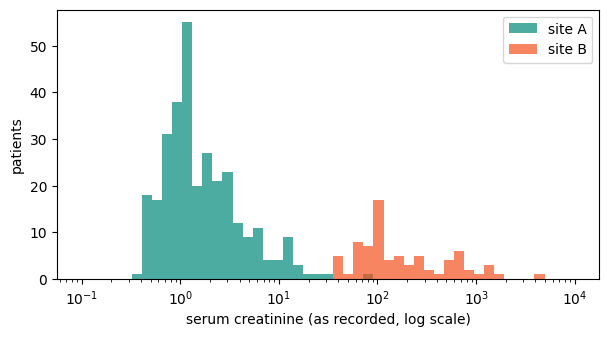

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.logspace(-1, 4, 50)
for site, color in [("A", "#00897B"), ("B", "#F4511E")]:
    ax.hist(ckd.loc[ckd["site"] == site, "sc"].dropna(), bins=bins, alpha=0.7,
            color=color, label=f"site {site}")
ax.set_xscale("log")
ax.set_xlabel("serum creatinine (as recorded, log scale)")
ax.set_ylabel("patients")
ax.legend()
plt.show()

既然知道醫院 B 用 µmol/L，就依來源換算回 mg/dL，再把 `site` 欄位拿掉（它只是我們注入的輔助欄，不該進模型）。

In [18]:
is_b = ckd["site"] == "B"
ckd.loc[is_b, "sc"] = ckd.loc[is_b, "sc"] / 88.4
ckd = ckd.drop(columns="site")

print("sc median after conversion:", round(ckd["sc"].median(), 2))

sc median after conversion: 1.3


## 5. 先切分，再前處理

從這裡開始，所有「會從資料學東西」的步驟（插補的中位數、標準化的平均與標準差、one-hot 的類別清單）都只能從**訓練集**學。所以第一步是切分。

In [19]:
from sklearn.model_selection import train_test_split

X = ckd.drop(columns="class")
y = (ckd["class"] == "ckd").astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print(X_train.shape, X_test.shape, "| CKD share in train:", y_train.mean().round(3))

(300, 24) (100, 24) | CKD share in train: 0.627


### 5-1 標準化 vs 正規化

血紅素（hemo）大約 3–18，白血球（wbcc）大約 2,000–26,000。兩種常見縮放：

- **標準化**（`StandardScaler`）：減平均、除以標準差，變成 z 分數。
- **正規化**（`MinMaxScaler`）：壓到 0 到 1 之間。

In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

demo = X_train[["hemo", "wbcc"]].dropna()
scaled = {
    "raw": demo,
    "standardized": pd.DataFrame(StandardScaler().fit_transform(demo), columns=demo.columns),
    "min-max": pd.DataFrame(MinMaxScaler().fit_transform(demo), columns=demo.columns),
}
for name, d in scaled.items():
    print(f"{name:>13}:", d.agg(["mean", "std", "min", "max"]).round(2).to_dict("list"))

          raw: {'hemo': [12.86, 3.01, 3.1, 17.8], 'wbcc': [8401.37, 3083.18, 2200.0, 26400.0]}
 standardized: {'hemo': [0.0, 1.0, -3.25, 1.65], 'wbcc': [-0.0, 1.0, -2.02, 5.85]}
      min-max: {'hemo': [0.66, 0.2, 0.0, 1.0], 'wbcc': [0.26, 0.13, 0.0, 1.0]}


### 5-2 把前處理裝進 Pipeline

`ColumnTransformer` 讓數值欄與類別欄各走各的處理，`Pipeline` 把前處理和模型串成一個整體。`fit` 的時候整條管線只看訓練集。

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

num_cols = X.select_dtypes("number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())])
categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
prep = ColumnTransformer([("num", numeric, num_cols), ("cat", categorical, cat_cols)])

model = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)
print("Test accuracy:", round(model.score(X_test, y_test), 3))

Test accuracy: 0.98


看看前處理之後的欄位：數值欄前綴 `num__`，類別欄被 one-hot 展開、前綴 `cat__`。

In [22]:
feature_names = model.named_steps["prep"].get_feature_names_out()
print(len(feature_names), "features")
print(feature_names[:5], "...", feature_names[-4:])

34 features
['num__age' 'num__bp' 'num__sg' 'num__al' 'num__su'] ... ['cat__pe_no' 'cat__pe_yes' 'cat__ane_no' 'cat__ane_yes']


### 5-3 測試集的混淆矩陣

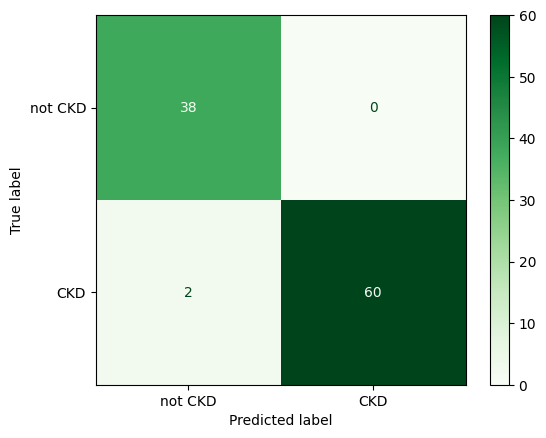

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
                                      display_labels=["not CKD", "CKD"], cmap="Greens")
plt.show()

## 6. 資料洩漏：故意做錯一次

用**純隨機雜訊**當資料：200 個「病人」、5,000 個毫無意義的特徵、標籤也是隨機的。正確答案應該是準確率 0.5 左右（猜硬幣）。

- **錯誤做法**：先用全部資料挑出與標籤最相關的 20 個特徵，再做交叉驗證。
- **正確做法**：把挑特徵放進 Pipeline，讓每一折只用該折的訓練資料挑。

In [24]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(42)
X_noise = rng.normal(size=(200, 5000))
y_noise = rng.integers(0, 2, size=200)

X_picked = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)  # sees ALL labels
wrong = cross_val_score(LogisticRegression(max_iter=1000), X_picked, y_noise, cv=5).mean()

pipe = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000))
right = cross_val_score(pipe, X_noise, y_noise, cv=5).mean()

print(f"Leaky  (select, then CV): {wrong:.2f}")
print(f"Proper (select inside CV): {right:.2f}")

Leaky  (select, then CV): 0.84
Proper (select inside CV): 0.55


錯誤做法在一堆雜訊上也能得到漂亮的準確率，因為挑特徵時已經「偷看」了驗證資料的答案。

## 7. 動手試試

1. 把第 4 節醫院 B 的比例從 `frac=0.2` 改成 `0.5`，對數直方圖的兩座山會怎麼變？如果**不知道**哪些病人來自醫院 B，你會怎麼判斷？
2. 在 5-2 節把數值欄的 `SimpleImputer(strategy="median")` 改成 `strategy="mean"`，或在 `SimpleImputer` 加上 `add_indicator=True`，測試準確率有沒有變化？想想 2-2 節的發現，加上遺漏指標欄是好事還是壞事？
3. 在第 6 節把 `k=20` 改成 `k=200`、或把特徵數 5000 改成 500，錯誤做法的準確率怎麼變？為什麼？